In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import mpltern
import pandas as pd
from matplotlib.ticker import NullLocator
from matplotlib.ticker import PercentFormatter

import pandas as pd
from scipy.stats import gaussian_kde

np.random.seed(19680801)
t1, l1, r1 = np.random.dirichlet(alpha=(2.0, 4.0, 8.0), size=100000).T
np.random.seed(0)
t2, l2, r2 = np.random.dirichlet(alpha=(8.0, 2.0, 3.0), size=100000).T

In [2]:

SMOOTHING = 1.5

# ---------------------------
# Helper 1: Ternary → Cartesian
# ---------------------------
def ternary_to_cartesian(t, l, r):
    """
    Convert ternary coordinates (t, l, r) into 2D Cartesian (x, y)
    inside an equilateral triangle.
    """
    s = t + l + r
    x = 0.5 * (2*r + t) / s
    y = (np.sqrt(3)/2) * t / s
    return x, y

# ---------------------------
# Helper 2: Fit KDE
# ---------------------------
def fit_kde(df):
    """
    Fit a Gaussian KDE to ternary data (df with 3 columns).
    """
    t, l, r = df.iloc[:,0].values, df.iloc[:,1].values, df.iloc[:,2].values
    x, y = ternary_to_cartesian(t, l, r)
    kde = gaussian_kde(np.vstack([x, y]), bw_method=SMOOTHING)
    return kde

# ---------------------------
# Helper 3: Evaluate KDE on uniform grid
# ---------------------------
def evaluate_kde_on_grid(kde, N=200):
    """
    Evaluate KDE on a uniform grid over the ternary simplex.
    Returns T, L, R, V arrays.
    """
    t_vals = np.linspace(0, 1, N)
    l_vals = np.linspace(0, 1, N)
    T, L = np.meshgrid(t_vals, l_vals)
    mask = (T + L <= 1)
    T, L = T[mask], L[mask]
    R = 1 - T - L

    X, Y = ternary_to_cartesian(T, L, R)
    V = kde(np.vstack([X, Y]))
    return T, L, R, V



In [3]:
def load_and_normalize_df(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df = df.drop(columns=['Unnamed: 0'])
    df = df.fillna(0)
    df = df.abs()
    row_sums = df.sum(axis=1)
    df_normalized = df.div(row_sums, axis=0).fillna(0)
    return df_normalized


In [4]:
def group_column_sums(df: pd.DataFrame, sens: list, foil: list) -> pd.DataFrame:
    # Compute sums
    list1 = sens
    list2 = foil
    sum_list1 = df[list1].mean(axis=1)
    sum_list2 = df[list2].mean(axis=1)
    
    # Remainder = all other columns
    remainder_cols = [c for c in df.columns if c not in set(list1 + list2)]
    sum_remainder = df[remainder_cols].mean(axis=1) if remainder_cols else 0

    return pd.DataFrame({
        "sens": sum_list1,
        "foil": sum_list2,
        "other": sum_remainder
    })


In [5]:
prefix = './RESULTS/'
def summarize(filepath, sens_feat, foil_feats, multiplier):
    df = load_and_normalize_df(f'{prefix}{filepath}')
    temp_res = group_column_sums(df, sens=[sens_feat], foil=foil_feats)
    sens = temp_res['sens'].tolist() * multiplier
    foil = temp_res['foil'].tolist() * multiplier
    other = temp_res['other'].tolist() * multiplier
    return sens, foil, other
    pass
    

In [6]:


def plot_ternary_hexbin(df_ones, df_twos, title="", label1="Data 1", label2="Data 2", bins='log', gridsize=10):
    """
    Plot two ternary hexbin plots with transparent colormaps.

    Parameters
    ----------
    df1 : pd.DataFrame
        First dataframe with exactly 3 columns.
    df2 : pd.DataFrame
        Second dataframe with exactly 3 columns.
    title : str
        Title of the plot.
    label1 : str
        Label for the first dataset colorbar.
    label2 : str
        Label for the second dataset colorbar.
    """

    # --- Build transparent Reds colormap ---
    reds = plt.cm.Oranges
    colors = reds(np.linspace(0, 1, 256))
    colors[:, -1] = np.linspace(0, 1, 256)
    transparent_reds = mpl.colors.ListedColormap(colors)

    # --- Build transparent Blues colormap ---
    blues = plt.cm.Blues
    colors = blues(np.linspace(0, 1, 256))
    colors[:, -1] = np.linspace(0, 1, 256)
    transparent_blues = mpl.colors.ListedColormap(colors)
    # transparent_blues = blues

    # --- Plot ---
    fig = plt.figure()
    ax = plt.subplot(projection="ternary")
    ax.tick_params(labelrotation='horizontal')

    # --- Extract ternary coords ---
    # gridsize=8
    const = 2000000 # low-tech KDE "melt" effect for viz.
    np.random.seed(0)
    for df1, df2 in zip(df_ones, df_twos):
        t1, l1, r1 = df1.iloc[:, 0], df1.iloc[:, 1], df1.iloc[:, 2]
        t2, l2, r2 = df2.iloc[:, 0], df2.iloc[:, 1], df2.iloc[:, 2]
        t1 = 100 * np.array(t1) + np.random.normal(size=len(t1)) / const
        l1 = 100 * np.array(l1) + np.random.normal(size=len(l1)) / const
        r1 = 100 * np.array(r1) + np.random.normal(size=len(r1)) / const
        t2 = 100 * np.array(t2) + np.random.normal(size=len(t2)) / const
        l2 = 100 * np.array(l2) + np.random.normal(size=len(l2)) / const
        r2 = 100 * np.array(r2) + np.random.normal(size=len(r2)) / const
    
        pc1 = ax.tribin(t1, l1, r1, edgecolors='none', cmap=transparent_blues, gridsize=gridsize, bins=bins)
        pc2 = ax.tribin(t2, l2, r2, edgecolors='none', cmap=transparent_reds, gridsize=gridsize, bins=bins)

    ax.set_title(title)

    # --- Add colorbars ---
    cax1 = ax.inset_axes([1.05, 0.1, 0.05, 0.4], transform=ax.transAxes)
    colorbar1 = fig.colorbar(pc1, cax=cax1, cmap='Blues')
    colorbar1.set_label(label1, rotation=270, va="baseline")
    # colorbar1.set_ticks([])
    # colorbar1.ax.tick_params(left=False, right=False, labelleft=False)
    
    cax2 = ax.inset_axes([1.052, 0.6, 0.05, 0.4], transform=ax.transAxes)
    colorbar2 = fig.colorbar(pc2, cax=cax2, cmap='Reds')
    colorbar2.set_label(label2, rotation=270, va="baseline")
    # colorbar2.set_ticks([])
    # colorbar2.ax.tick_params(left=False, right=False, labelleft=False)
    
    colorbar1.ax.yaxis.set_major_locator(NullLocator())
    colorbar1.ax.yaxis.set_minor_locator(NullLocator())
    
    colorbar2.ax.yaxis.set_major_locator(NullLocator())
    colorbar2.ax.yaxis.set_minor_locator(NullLocator())


    ax.set_tlabel('↖ Sensitive\n   ↖ Feature')
    ax.set_llabel('Foil ↙\nFeature ↙   ')
    ax.set_rlabel('→ Other Features →')
    # ax.set_tlabel('Sensitive\n↖ Feature')
    # ax.set_llabel('Foil ↙\nFeature(s)')
    # ax.set_rlabel('Other Features →')    

    ax.taxis.set_label_rotation_mode('horizontal')
    ax.laxis.set_label_rotation_mode('horizontal')
    ax.raxis.set_label_rotation_mode('horizontal')

    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')

    ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labelst = ["0%", "20%", "40%", "60%", "80%", "100% "]
    labelsl = ["0%", "20%", "40%", "60%", "80%", "100% "]
    labelsr = ["0%", "20%", "40%", "60%", "80%", "100% "]
    ax.taxis.set_ticks(ticks, labels=labelst)
    ax.laxis.set_ticks(ticks, labels=labelsl)
    ax.raxis.set_ticks(ticks, labels=labelsr)

    plt.tight_layout()

    # plt.show()
    return fig, ax


In [7]:

def transparent_cmap_def(color, n=256):
    """
    Create a colormap going from transparent to the given color.

    Parameters
    ----------
    color : str or tuple
        Any valid matplotlib color (e.g., "C0", "C1", "#ff0000", (r,g,b)).
    n : int
        Number of levels in the colormap.

    Returns
    -------
    cmap : matplotlib.colors.ListedColormap
        Colormap going from transparent to the given color.
    """
    # Convert color to RGBA (force alpha=1 for base color)
    rgba = np.array(mpl.colors.to_rgba(color))
    rgba = np.tile(rgba, (n, 1))  # repeat n times
    rgba[:, -1] = np.linspace(0, 1, n)  # alpha gradient
    return mpl.colors.ListedColormap(rgba)

def transparent_cmap(color, n=256, bg="white", alpha_power=1.5):
    """
    Create a colormap going from transparent background to the given color.

    Parameters
    ----------
    color : str or tuple
        Any valid matplotlib color (e.g., "C0", "C1", "#ff0000", (r,g,b)).
    n : int
        Number of levels in the colormap.
    bg : str or tuple
        Background color to fade from (default: white).
    alpha_power : float
        Adjust how fast alpha ramps up ( >1 = more transparent part).
    """
    # Convert colors to RGB
    rgb_target = np.array(mpl.colors.to_rgb(color))
    rgb_bg = np.array(mpl.colors.to_rgb(bg))

    # Interpolation 0→1
    t = np.linspace(0, 1, n)

    # Fade RGB from background → target
    rgbs = (1 - t)[:, None] * rgb_bg + t[:, None] * rgb_target

    # Nonlinear alpha ramp
    alphas = t**alpha_power

    rgba = np.concatenate([rgbs, alphas[:, None]], axis=1)
    return mpl.colors.ListedColormap(rgba)

# Example colormaps for matplotlib defaults C0, C1, C3
transparent_c0 = transparent_cmap("C0")
transparent_c1 = transparent_cmap("C1")
transparent_c3 = transparent_cmap("C3")

In [8]:

def plot_ternary_dists(df_ones, df_twos, title="", label1="Data 1", label2="Data 2"):
    """
    Plot two ternary hexbin plots with transparent colormaps.

    Parameters
    ----------
    df1 : pd.DataFrame
        First dataframe with exactly 3 columns.
    df2 : pd.DataFrame
        Second dataframe with exactly 3 columns.
    title : str
        Title of the plot.
    label1 : str
        Label for the first dataset colorbar.
    label2 : str
        Label for the second dataset colorbar.
    """

    # --- Build transparent colormaps ---
    # reds = plt.cm.Oranges
    # colors = reds(np.linspace(0, 1, 256))
    # colors[:, -1] = np.linspace(0, 1, 256)
    # transparent_reds = mpl.colors.ListedColormap(colors)
    rot_cmap = transparent_c0
    shap_cmap = transparent_c1
    lime_cmap = transparent_c3

    # blues = plt.cm.Blues
    # colors = blues(np.linspace(0, 1, 256))
    # colors[:, -1] = np.linspace(0, 1, 256)
    # transparent_blues = mpl.colors.ListedColormap(colors)

    # purples = plt.cm.Purples
    # colors = purples(np.linspace(0, 1, 256))
    # colors[:, -1] = np.linspace(0, 1, 256)
    # transparent_purples = mpl.colors.ListedColormap(colors)

    # --- Plot ---
    fig = plt.figure()
    ax = plt.subplot(projection="ternary")
    ax.tick_params(labelrotation='horizontal', labelsize=11)

    # --- Extract ternary coords ---
    # gridsize=8
    const = 2000000 # low-tech KDE "melt" effect for viz.
    np.random.seed(0)
    for df1, df2 in zip(df_ones, df_twos):
        evals = 200
        levels = 500
        kde = fit_kde(df1)
        T, L, R, V = evaluate_kde_on_grid(kde, evals)
        c_map = shap_cmap
        if label1 == 'LIME':
            c_map = lime_cmap
        pc1 = ax.tricontourf(T, L, R, V, levels=levels, cmap=c_map)
        kde = fit_kde(df2)
        T, L, R, V = evaluate_kde_on_grid(kde, evals)
        pc2 = ax.tricontourf(T, L, R, V, levels=levels, cmap=rot_cmap)

        # t1 = 100 * np.array(t1) + np.random.normal(size=len(t1)) / const
        # l1 = 100 * np.array(l1) + np.random.normal(size=len(l1)) / const
        # r1 = 100 * np.array(r1) + np.random.normal(size=len(r1)) / const
        # t2 = 100 * np.array(t2) + np.random.normal(size=len(t2)) / const
        # l2 = 100 * np.array(l2) + np.random.normal(size=len(l2)) / const
        # r2 = 100 * np.array(r2) + np.random.normal(size=len(r2)) / const
    
        # pc1 = ax.tribin(t1, l1, r1, edgecolors='none', cmap=transparent_blues, gridsize=gridsize, bins=bins)
        # pc2 = ax.tribin(t2, l2, r2, edgecolors='none', cmap=transparent_reds, gridsize=gridsize, bins=bins)

    ax.set_title(title)

    # --- Add colorbars ---
    cax1 = ax.inset_axes([1.05, 0.1, 0.05, 0.4], transform=ax.transAxes)
    colorbar1 = fig.colorbar(pc1, cax=cax1, cmap=lime_cmap if label1 == 'LIME' else shap_cmap)
    colorbar1.set_label(label1, rotation=270, va="baseline")
    # colorbar1.set_ticks([])
    # colorbar1.ax.tick_params(left=False, right=False, labelleft=False)
    
    cax2 = ax.inset_axes([1.052, 0.6, 0.05, 0.4], transform=ax.transAxes)
    colorbar2 = fig.colorbar(pc2, cax=cax2, cmap=rot_cmap)
    colorbar2.set_label(label2, rotation=270, va="baseline")
    # colorbar2.set_ticks([])
    # colorbar2.ax.tick_params(left=False, right=False, labelleft=False)
    
    colorbar1.ax.yaxis.set_major_locator(NullLocator())
    colorbar1.ax.yaxis.set_minor_locator(NullLocator())
    
    colorbar2.ax.yaxis.set_major_locator(NullLocator())
    colorbar2.ax.yaxis.set_minor_locator(NullLocator())


    # ax.set_tlabel('↖ Sensitive\n   ↖ Feature')
    # ax.set_llabel('Foil ↙\nFeature ↙   ')
    # ax.set_rlabel('→ Other Features →')
    # ax.set_tlabel('Sensitive\n↖ Feature')
    # ax.set_llabel('Foil ↙\nFeature(s)')
    # ax.set_rlabel('Other Features →')    
    ax.set_tlabel('← Sensitive Feature', fontsize=13)
    ax.set_llabel('← Foil Feature(s)', fontsize=13)
    ax.set_rlabel('All Other Features →', fontsize=13)

    # ax.taxis.set_label_rotation_mode('horizontal')
    # ax.laxis.set_label_rotation_mode('horizontal')
    # ax.raxis.set_label_rotation_mode('horizontal')

    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')

    ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    labelst = ["0%", "20%", "40%", "60%", "80%", "100% "]
    labelsl = ["0%", "20%", "40%", "60%", "80%", "100% "]
    labelsr = ["0%", "20%", "40%", "60%", "80%", "100% "]
    ax.taxis.set_ticks(ticks, labels=labelst)
    ax.laxis.set_ticks(ticks, labels=labelsl)
    ax.raxis.set_ticks(ticks, labels=labelsr)

    plt.tight_layout()

    # plt.show()
    return fig, ax


In [9]:

# plot_ternary_hexbin([pd.DataFrame({'sens': t1, 'foil': l1, 'other': r1})], [pd.DataFrame({'sens': t2, 'foil': l2, 'other': r2})], bins='log', gridsize=50)

# plot_ternary_dists([pd.DataFrame({'sens': t1, 'foil': l1, 'other': r1})], [pd.DataFrame({'sens': t2, 'foil': l2, 'other': r2})])


In [10]:
def append_summarize(alls, allf, allo, fpath, sens, foils, multiplier):
    # multiplier = 1
    _s, _f, _o = summarize(fpath, sens, foils, multiplier)
    alls += _s
    allf += _f
    allo += _o
    return alls, allf, allo


In [11]:

llime_s, llime_f, llime_o = [], [], []
rlime_s, rlime_f, rlime_o = [], [], []
sshap_s, sshap_f, sshap_o = [], [], []
rshap_s, rshap_f, rshap_o = [], [], []

print()
print(f'{len(llime_s)=}\t{len(llime_f)=}\t{len(llime_o)=}')
print(f'{len(rlime_s)=}\t{len(rlime_f)=}\t{len(rlime_o)=}')
print(f'{len(sshap_s)=}\t{len(sshap_f)=}\t{len(sshap_o)=}')
print(f'{len(rshap_s)=}\t{len(rshap_f)=}\t{len(rshap_o)=}')
print('INIT')
print()

llime_s, llime_f, llime_o = append_summarize(llime_s, llime_f, llime_o, 'german/lime_exps_ml.csv', 'Gender', ['LoanRateAsPercentOfIncome'], 618)
rlime_s, rlime_f, rlime_o = append_summarize(rlime_s, rlime_f, rlime_o, 'german/rot_exps_ml.csv', 'Gender', ['LoanRateAsPercentOfIncome'], 618)
sshap_s, sshap_f, sshap_o = append_summarize(sshap_s, sshap_f, sshap_o, 'german/shap_exps_ms.csv', 'Gender', ['LoanRateAsPercentOfIncome'], 618)
rshap_s, rshap_f, rshap_o = append_summarize(rshap_s, rshap_f, rshap_o, 'german/rot_exps_ms.csv', 'Gender', ['LoanRateAsPercentOfIncome'], 618)
print(f'{len(llime_s)=}\t{len(llime_f)=}\t{len(llime_o)=}')
print(f'{len(rlime_s)=}\t{len(rlime_f)=}\t{len(rlime_o)=}')
print(f'{len(sshap_s)=}\t{len(sshap_f)=}\t{len(sshap_o)=}')
print(f'{len(rshap_s)=}\t{len(rshap_f)=}\t{len(rshap_o)=}')
print('GERMAN')
print()

llime_s_g1, llime_f_g1, llime_o_g1 = llime_s, llime_f, llime_o
rlime_s_g1, rlime_f_g1, rlime_o_g1 = rlime_s, rlime_f, rlime_o
sshap_s_g1, sshap_f_g1, sshap_o_g1 = sshap_s, sshap_f, sshap_o
rshap_s_g1, rshap_f_g1, rshap_o_g1 = rshap_s, rshap_f, rshap_o
llime_s, llime_f, llime_o = [], [], []
rlime_s, rlime_f, rlime_o = [], [], []
sshap_s, sshap_f, sshap_o = [], [], []
rshap_s, rshap_f, rshap_o = [], [], []




llime_s, llime_f, llime_o = append_summarize(llime_s, llime_f, llime_o, 'compas/lime_exps_ml1.csv', 'race', ['unrelated_column_one'], 100)
rlime_s, rlime_f, rlime_o = append_summarize(rlime_s, rlime_f, rlime_o, 'compas/rot_exps_ml1.csv', 'race', ['unrelated_column_one'], 100)
sshap_s, sshap_f, sshap_o = append_summarize(sshap_s, sshap_f, sshap_o, 'compas/shap_exps_ms1.csv', 'race', ['unrelated_column_one'], 100)
rshap_s, rshap_f, rshap_o = append_summarize(rshap_s, rshap_f, rshap_o, 'compas/rot_exps_ms1.csv', 'race', ['unrelated_column_one'], 100)

llime_s_c1, llime_f_c1, llime_o_c1 = llime_s, llime_f, llime_o
rlime_s_c1, rlime_f_c1, rlime_o_c1 = rlime_s, rlime_f, rlime_o
sshap_s_c1, sshap_f_c1, sshap_o_c1 = sshap_s, sshap_f, sshap_o
rshap_s_c1, rshap_f_c1, rshap_o_c1 = rshap_s, rshap_f, rshap_o
llime_s, llime_f, llime_o = [], [], []
rlime_s, rlime_f, rlime_o = [], [], []
sshap_s, sshap_f, sshap_o = [], [], []
rshap_s, rshap_f, rshap_o = [], [], []

llime_s, llime_f, llime_o = append_summarize(llime_s, llime_f, llime_o, 'compas/lime_exps_ml2.csv', 'race', ['unrelated_column_one', 'unrelated_column_two'], 100)
rlime_s, rlime_f, rlime_o = append_summarize(rlime_s, rlime_f, rlime_o, 'compas/rot_exps_ml2.csv', 'race', ['unrelated_column_one', 'unrelated_column_two'], 100)
sshap_s, sshap_f, sshap_o = append_summarize(sshap_s, sshap_f, sshap_o, 'compas/shap_exps_ms2.csv', 'race', ['unrelated_column_one', 'unrelated_column_two'], 100)
rshap_s, rshap_f, rshap_o = append_summarize(rshap_s, rshap_f, rshap_o, 'compas/rot_exps_ms2.csv', 'race', ['unrelated_column_one', 'unrelated_column_two'], 100)
print(f'{len(llime_s)=}\t{len(llime_f)=}\t{len(llime_o)=}')
print(f'{len(rlime_s)=}\t{len(rlime_f)=}\t{len(rlime_o)=}')
print(f'{len(sshap_s)=}\t{len(sshap_f)=}\t{len(sshap_o)=}')
print(f'{len(rshap_s)=}\t{len(rshap_f)=}\t{len(rshap_o)=}')
print('COMPAS')
print()

llime_s_c2, llime_f_c2, llime_o_c2 = llime_s, llime_f, llime_o
rlime_s_c2, rlime_f_c2, rlime_o_c2 = rlime_s, rlime_f, rlime_o
sshap_s_c2, sshap_f_c2, sshap_o_c2 = sshap_s, sshap_f, sshap_o
rshap_s_c2, rshap_f_c2, rshap_o_c2 = rshap_s, rshap_f, rshap_o
llime_s, llime_f, llime_o = [], [], []
rlime_s, rlime_f, rlime_o = [], [], []
sshap_s, sshap_f, sshap_o = [], [], []
rshap_s, rshap_f, rshap_o = [], [], []







llime_s, llime_f, llime_o = append_summarize(llime_s, llime_f, llime_o, 'cc/lime_exps_ml1.csv', 'racePctWhite numeric', ['unrelated_column_one'], 309)
rlime_s, rlime_f, rlime_o = append_summarize(rlime_s, rlime_f, rlime_o, 'cc/rot_exps_ml1.csv', 'racePctWhite numeric', ['unrelated_column_one'], 309)
sshap_s, sshap_f, sshap_o = append_summarize(sshap_s, sshap_f, sshap_o, 'cc/shap_exps_ms1.csv', 'racePctWhite numeric', ['unrelated_column_one'], 309)
rshap_s, rshap_f, rshap_o = append_summarize(rshap_s, rshap_f, rshap_o, 'cc/rot_exps_ms1.csv', 'racePctWhite numeric', ['unrelated_column_one'], 309)


llime_s_cc1, llime_f_cc1, llime_o_cc1 = llime_s, llime_f, llime_o
rlime_s_cc1, rlime_f_cc1, rlime_o_cc1 = rlime_s, rlime_f, rlime_o
sshap_s_cc1, sshap_f_cc1, sshap_o_cc1 = sshap_s, sshap_f, sshap_o
rshap_s_cc1, rshap_f_cc1, rshap_o_cc1 = rshap_s, rshap_f, rshap_o
llime_s, llime_f, llime_o = [], [], []
rlime_s, rlime_f, rlime_o = [], [], []
sshap_s, sshap_f, sshap_o = [], [], []
rshap_s, rshap_f, rshap_o = [], [], []

llime_s, llime_f, llime_o = append_summarize(llime_s, llime_f, llime_o, 'cc/lime_exps_ml2.csv', 'racePctWhite numeric', ['unrelated_column_one', 'unrelated_column_two'], 309)
rlime_s, rlime_f, rlime_o = append_summarize(rlime_s, rlime_f, rlime_o, 'cc/rot_exps_ml2.csv', 'racePctWhite numeric', ['unrelated_column_one', 'unrelated_column_two'], 309)
sshap_s, sshap_f, sshap_o = append_summarize(sshap_s, sshap_f, sshap_o, 'cc/shap_exps_ms2.csv', 'racePctWhite numeric', ['unrelated_column_one', 'unrelated_column_two'], 309)
rshap_s, rshap_f, rshap_o = append_summarize(rshap_s, rshap_f, rshap_o, 'cc/rot_exps_ms2.csv', 'racePctWhite numeric', ['unrelated_column_one', 'unrelated_column_two'], 309)
print(f'{len(llime_s)=}\t{len(llime_f)=}\t{len(llime_o)=}')
print(f'{len(rlime_s)=}\t{len(rlime_f)=}\t{len(rlime_o)=}')
print(f'{len(sshap_s)=}\t{len(sshap_f)=}\t{len(sshap_o)=}')
print(f'{len(rshap_s)=}\t{len(rshap_f)=}\t{len(rshap_o)=}')
print('CC')
print()

llime_s_cc2, llime_f_cc2, llime_o_cc2 = llime_s, llime_f, llime_o
rlime_s_cc2, rlime_f_cc2, rlime_o_cc2 = rlime_s, rlime_f, rlime_o
sshap_s_cc2, sshap_f_cc2, sshap_o_cc2 = sshap_s, sshap_f, sshap_o
rshap_s_cc2, rshap_f_cc2, rshap_o_cc2 = rshap_s, rshap_f, rshap_o

llime_s = llime_s_g1 + llime_s_c1 + llime_s_c2 + llime_s_cc1 + llime_s_cc2
llime_f = llime_f_g1 + llime_f_c1 + llime_f_c2 + llime_f_cc1 + llime_f_cc2
llime_o = llime_o_g1 + llime_o_c1 + llime_o_c2 + llime_o_cc1 + llime_o_cc2
rlime_s = rlime_s_g1 + rlime_s_c1 + rlime_s_c2 + rlime_s_cc1 + rlime_s_cc2
rlime_f = rlime_f_g1 + rlime_f_c1 + rlime_f_c2 + rlime_f_cc1 + rlime_f_cc2
rlime_o = rlime_o_g1 + rlime_o_c1 + rlime_o_c2 + rlime_o_cc1 + rlime_o_cc2
sshap_s = sshap_s_g1 + sshap_s_c1 + sshap_s_c2 + sshap_s_cc1 + sshap_s_cc2
sshap_f = sshap_f_g1 + sshap_f_c1 + sshap_f_c2 + sshap_f_cc1 + sshap_f_cc2
sshap_o = sshap_o_g1 + sshap_o_c1 + sshap_o_c2 + sshap_o_cc1 + sshap_o_cc2
rshap_s = rshap_s_g1 + rshap_s_c1 + rshap_s_c2 + rshap_s_cc1 + rshap_s_cc2
rshap_f = rshap_f_g1 + rshap_f_c1 + rshap_f_c2 + rshap_f_cc1 + rshap_f_cc2
rshap_o = rshap_o_g1 + rshap_o_c1 + rshap_o_c2 + rshap_o_cc1 + rshap_o_cc2





len(llime_s)=0	len(llime_f)=0	len(llime_o)=0
len(rlime_s)=0	len(rlime_f)=0	len(rlime_o)=0
len(sshap_s)=0	len(sshap_f)=0	len(sshap_o)=0
len(rshap_s)=0	len(rshap_f)=0	len(rshap_o)=0
INIT

len(llime_s)=61800	len(llime_f)=61800	len(llime_o)=61800
len(rlime_s)=61800	len(rlime_f)=61800	len(rlime_o)=61800
len(sshap_s)=61800	len(sshap_f)=61800	len(sshap_o)=61800
len(rshap_s)=61800	len(rshap_f)=61800	len(rshap_o)=61800
GERMAN

len(llime_s)=61800	len(llime_f)=61800	len(llime_o)=61800
len(rlime_s)=61800	len(rlime_f)=61800	len(rlime_o)=61800
len(sshap_s)=61800	len(sshap_f)=61800	len(sshap_o)=61800
len(rshap_s)=61800	len(rshap_f)=61800	len(rshap_o)=61800
COMPAS

len(llime_s)=61800	len(llime_f)=61800	len(llime_o)=61800
len(rlime_s)=61800	len(rlime_f)=61800	len(rlime_o)=61800
len(sshap_s)=61800	len(sshap_f)=61800	len(sshap_o)=61800
len(rshap_s)=61800	len(rshap_f)=61800	len(rshap_o)=61800
CC



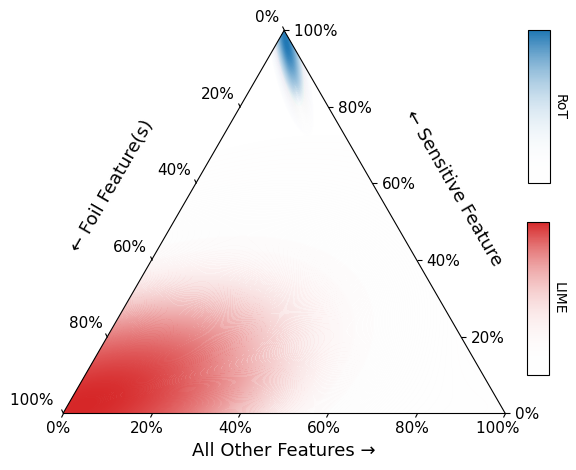

In [12]:

df1 = [
    pd.DataFrame({'sens': llime_s, 'foil': llime_f, 'other': llime_o}),
]
df2 = [
    pd.DataFrame({'sens': rlime_s, 'foil': rlime_f, 'other': rlime_o}),
]
# fig, ax = plot_ternary_hexbin(df1, df2, title='equiweighted explanations', label1='LIME', label2='RoT', gridsize=6, bins='log')
# fig, ax = plot_ternary_hexbin(df1, df2, title='', label1='LIME', label2='RoT', gridsize=6, bins='log')
fig, ax = plot_ternary_dists(df1, df2, title='', label1='LIME', label2='RoT')
plt.savefig('./RESULTS/PLOTS/triangle_lime_rot.png', dpi=300)
plt.savefig('./RESULTS/PLOTS/triangle_lime_rot.pdf', dpi=300)


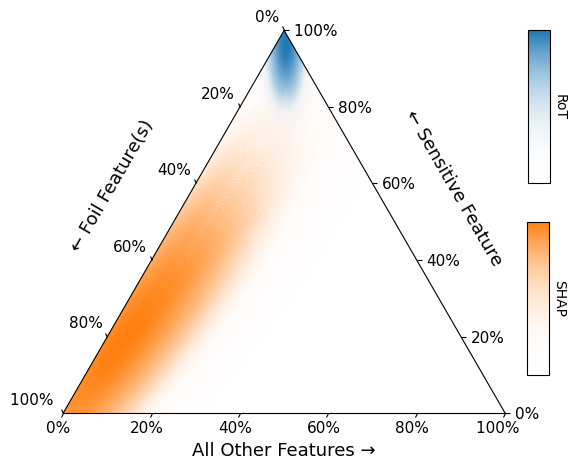

In [13]:

df1 = [
    pd.DataFrame({'sens': sshap_s, 'foil': sshap_f, 'other': sshap_o}),
]
df2 = [
    pd.DataFrame({'sens': rshap_s, 'foil': rshap_f, 'other': rshap_o}),
]
# plot_ternary_hexbin(df1, df2, title='equiweighted explanations', label1='SHAP', label2='RoT', gridsize=6, bins='log')
# plot_ternary_hexbin(df1, df2, title='', label1='SHAP', label2='RoT', gridsize=6, bins='log')
plot_ternary_dists(df1, df2, title='', label1='SHAP', label2='RoT')
plt.savefig('./RESULTS/PLOTS/triangle_shap_rot.png', dpi=300)
plt.savefig('./RESULTS/PLOTS/triangle_shap_rot.pdf', dpi=300)
